# Classification Part A: Software Defect Prediction

Import the necessary libraries for data manipulation, visualization, machine learning models, and evaluation metrics.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

### Load the Dataset
### Check Dataset Size and Missing Values
The shape of the dataset tells us the total number of observations and variables.
* Rows represent individual software modules.
* Columns represent different structural features.

In [6]:
df = pd.read_csv('../data/SoftwareDefectDataset.csv')
target_col = 'DEFECT_LABEL'

print("--- Dataset Audit ---")
print(f"Shape: {df.shape}")
print(f"Missing Values:\n{df.isnull().sum().max()} max per column")
print(f"\nTarget Class Distribution:\n{df[target_col].value_counts()}")

--- Dataset Audit ---
Shape: (1000, 11)
Missing Values:
0 max per column

Target Class Distribution:
DEFECT_LABEL
0    674
1    326
Name: count, dtype: int64


### Exploratory Data Analysis (EDA) Visualizations
Generate distribution plots, a correlation heatmap, and scatter plots to understand relationships between code size (LOC), complexity (CYCLO), and software defects.

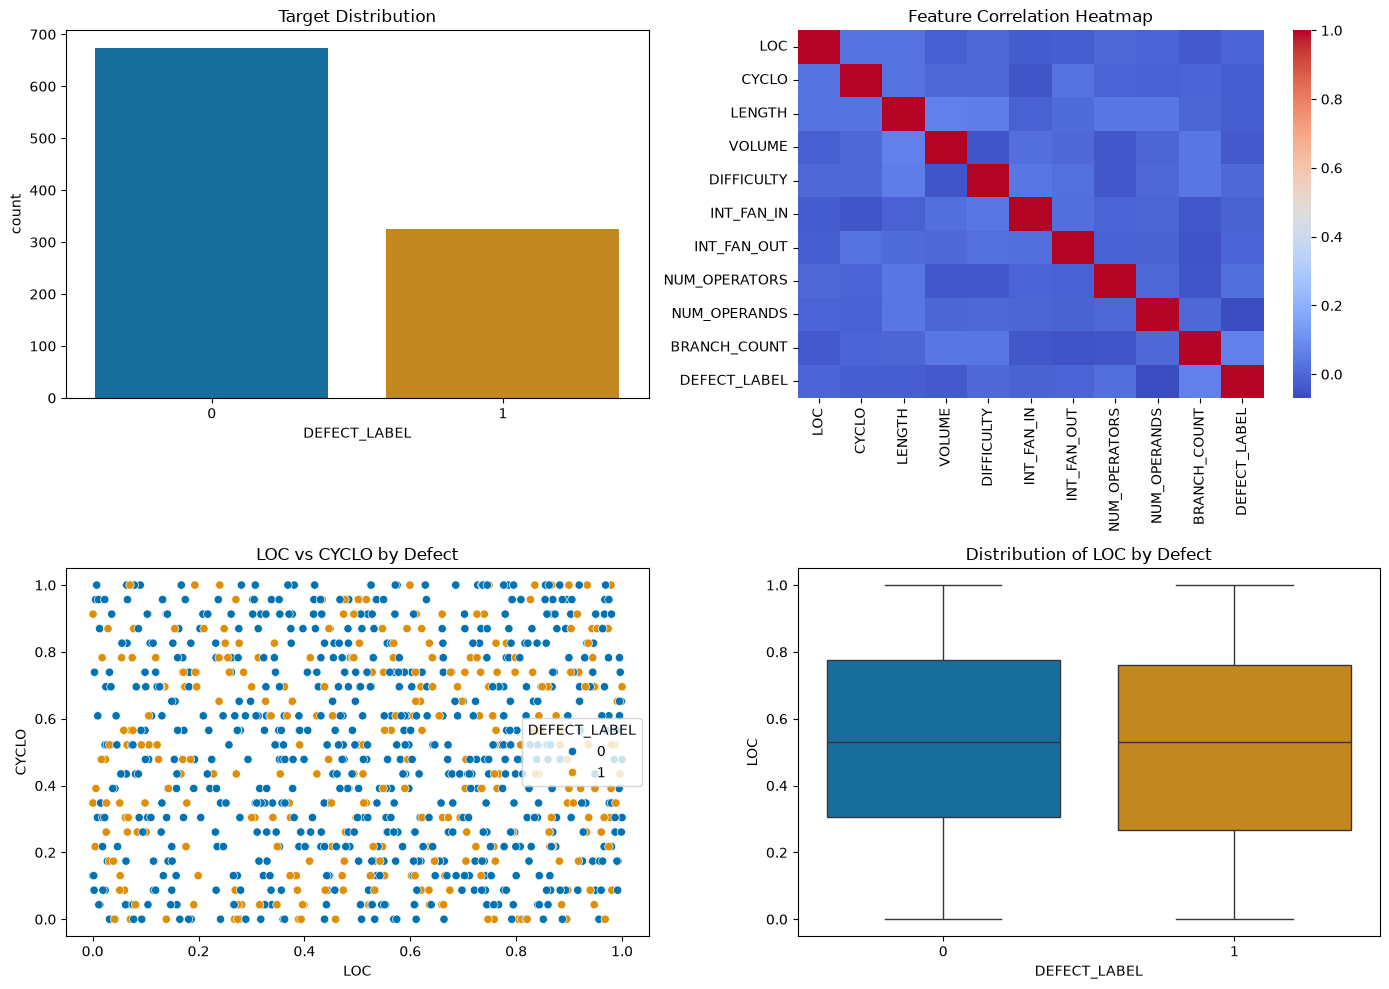

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Target Distribution (Fixed FutureWarning)
sns.countplot(data=df, x=target_col, hue=target_col, palette='colorblind', legend=False, ax=axes[0, 0])
axes[0, 0].set_title('Target Distribution')

# Correlation Heatmap
numeric_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm', ax=axes[0, 1])
axes[0, 1].set_title('Feature Correlation Heatmap')

# Scatter Plot: LOC vs CYCLO 
# (This one was fine because hue was already assigned to target_col)
sns.scatterplot(data=df, x='LOC', y='CYCLO', hue=target_col, palette='colorblind', ax=axes[1, 0])
axes[1, 0].set_title('LOC vs CYCLO by Defect')

# Box Plot: LOC Distribution (Fixed FutureWarning)
sns.boxplot(data=df, x=target_col, y='LOC', hue=target_col, palette='colorblind', legend=False, ax=axes[1, 1])
axes[1, 1].set_title('Distribution of LOC by Defect')

plt.tight_layout()
plt.show()

### Data Preprocessing and Splitting
Drop missing values and split the dataset into training and testing sets (80:20) using a stratified split to maintain the class ratio.

In [15]:
df = df.dropna()
X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

### Feature Engineering
Create a new feature `Complexity_Density` by dividing structural complexity by the lines of code. This engineered feature may improve performance by highlighting modules that are disproportionately complex for their size.

In [16]:
X_train = X_train.copy()
X_test = X_test.copy()

X_train['Complexity_Density'] = X_train['CYCLO'] / (X_train['LOC'] + 1)
X_test['Complexity_Density'] = X_test['CYCLO'] / (X_test['LOC'] + 1)

### Feature Scaling
Apply `StandardScaler` to normalize the features. It is fitted exclusively on the training set to prevent data leakage.

In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Model Training and Evaluation (Part A)
Train the five required baseline algorithms (Logistic Regression, KNN, Gaussian NB, Decision Tree, SVC) and evaluate them using Accuracy, Weighted F1-score, and Confusion Matrices.


--- Logistic Regression Confusion Matrix ---
[[133   2]
 [ 65   0]]

--- KNN (k=5) Confusion Matrix ---
[[103  32]
 [ 53  12]]

--- Gaussian NB Confusion Matrix ---
[[133   2]
 [ 65   0]]

--- Decision Tree Confusion Matrix ---
[[126   9]
 [ 62   3]]

--- SVC Confusion Matrix ---
[[135   0]
 [ 65   0]]


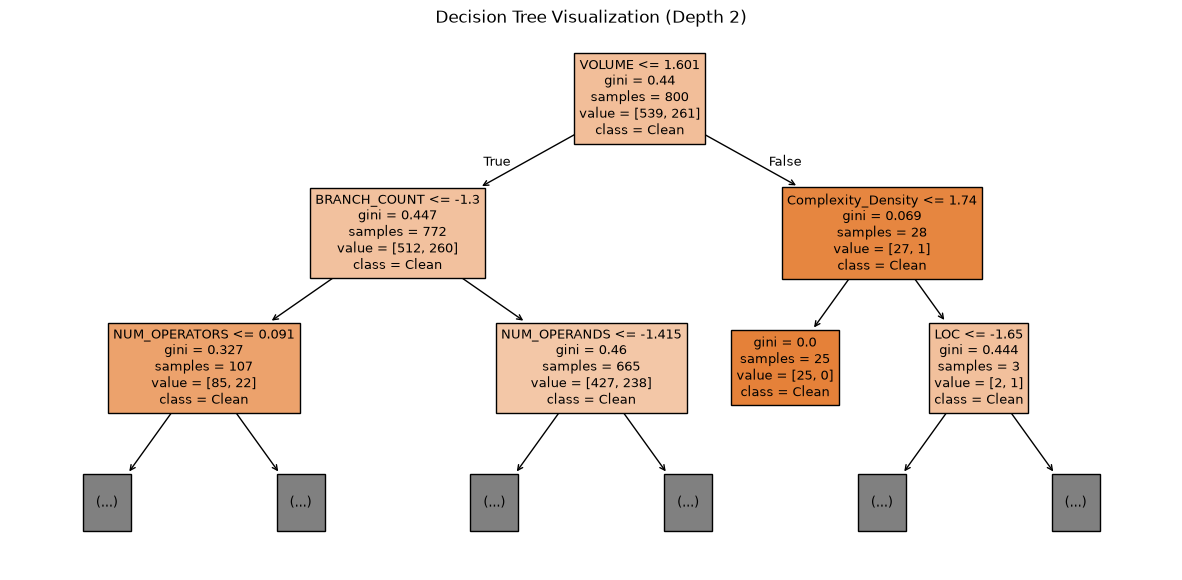

In [18]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5, metric='minkowski'),
    'Gaussian NB': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(max_depth=4, random_state=42),
    'SVC': SVC(C=1.0, kernel='rbf', random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average='weighted')
    cm = confusion_matrix(y_test, preds)
    
    results.append({'Model': name, 'Accuracy': acc, 'Weighted F1': f1})
    print(f"\n--- {name} Confusion Matrix ---")
    print(cm)

# Display Decision Tree visually
plt.figure(figsize=(15, 7))
plot_tree(models['Decision Tree'], filled=True, feature_names=list(X_train.columns), class_names=['Clean', 'Defect'], max_depth=2)
plt.title("Decision Tree Visualization (Depth 2)")
plt.show()

### Final Comparison Table
Consolidate the evaluation metrics for all five models into a single summary table ranked by Weighted F1-score.

In [19]:
results_df = pd.DataFrame(results).sort_values(by='Weighted F1', ascending=False)
display(results_df)

,Model,Accuracy,Weighted F1
3,Decision Tree,0.645,0.551950
1,KNN (k=5),0.575,0.549395
4,SVC,0.675,0.544030
0,Logistic Regression,0.665,0.539189
2,Gaussian NB,0.665,0.539189
